# CIC-IDS2017: preprocessing and feature selection


Two label columns are created (is_attack and attack_category):

| Column | Meaning | Used by |
| --- | --- | --- |
| `is_attack` | 0 for benign traffic, 1 for an attack | Binary intrusion detection |
| `attack_category` | `BENIGN` or the name of the attack | Attack-type classification |
| `attack_label` | the original CIC-IDS2017 label | reference only |

## 1. Imports and settings

In [1]:
from pathlib import Path
import json
import math

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42
TEST_SIZE = 0.20
SAMPLE_SIZE = 200_000
TOP_FEATURES = 20


CORRELATION_LIMIT = 0.95

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CSV_FOLDER = PROJECT_ROOT / "dataset/CSVs/MachineLearningCSV"
PCAP_FOLDER = PROJECT_ROOT / "dataset/PCAPs"
PROCESSED_FOLDER = PROJECT_ROOT / "dataset/processed"
FEATURE_FOLDER = PROJECT_ROOT / "artifacts/feature_selection"

RUN_PREPROCESSING = True
RUN_FEATURE_SELECTION = True

## 2. Input files


In [2]:
csv_files = sorted(CSV_FOLDER.glob("*.csv"))
# pcap_files = sorted(PCAP_FOLDER.rglob("*.pcap")) if PCAP_FOLDER.exists() else []

print(f"CSV files:  {len(csv_files)}")
# print(f"PCAP files: {len(pcap_files)}")
pd.DataFrame({
    "CSV file": [file.name for file in csv_files],
    "Size (MB)": [round(file.stat().st_size / 1024**2, 2) for file in csv_files],
})

CSV files:  8


,CSV file,Size (MB)
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,73.55
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,73.34
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,55.62
3,Monday-WorkingHours.pcap_ISCX.csv,168.73
4,Thursday-WorkingHours-Afternoon-Infilteration....,79.25
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,49.61
6,Tuesday-WorkingHours.pcap_ISCX.csv,128.82
7,Wednesday-workingHours.pcap_ISCX.csv,214.74


## 3. Load all CSV files

In [3]:
def load_csv_files(files):
    dataframes = []
    for file in tqdm(files, desc="Reading CSV files", unit="file"):
        dataframes.append(pd.read_csv(file, low_memory=False))
    return pd.concat(dataframes, ignore_index=True)

In [4]:
if RUN_PREPROCESSING:
    raw_data = load_csv_files(csv_files)
    print(f"Rows: {len(raw_data):,}")
    print(f"Columns: {len(raw_data.columns)}")
    display(raw_data.head())
else:
    print("Skipped. Set RUN_PREPROCESSING = True to load all raw CSV files.")

Reading CSV files:   0%|          | 0/8 [00:00<?, ?file/s]

Rows: 2,830,743
Columns: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 4. Label names and attack categories

In [5]:
# Characters that must become a plain hyphen. U+FFFD is the replacement
# character that pandas produces for the broken byte in the CSV files.
DAMAGED_SEPARATORS = (chr(0xFFFD), chr(0x96), chr(0x2013), chr(0x2014))

ATTACK_CATEGORIES = {
    "Web Attack - Brute Force": "Web Attack",
    "Web Attack - Sql Injection": "Web Attack",
    "Web Attack - XSS": "Web Attack",
}


def clean_label_names(labels):
    cleaned = labels.astype("string").str.strip()
    for character in DAMAGED_SEPARATORS:
        cleaned = cleaned.str.replace(character, "-", regex=False)
    return cleaned.str.replace(r"\s+", " ", regex=True)


def to_category(labels):
    return labels.map(lambda name: ATTACK_CATEGORIES.get(name, name)).astype("string")


example = pd.Series(["FTP-Patator", "Web Attack " + chr(0xFFFD) + " XSS",
                     " BENIGN ", "DDoS"])
pd.DataFrame({
    "raw label": example,
    "attack_label": clean_label_names(example),
    "attack_category": to_category(clean_label_names(example)),
})

,raw label,attack_label,attack_category
0,FTP-Patator,FTP-Patator,FTP-Patator
1,Web Attack � XSS,Web Attack - XSS,Web Attack
2,BENIGN,BENIGN,BENIGN
3,DDoS,DDoS,DDoS


## 5. Clean the data

In [7]:
LABEL_COLUMNS = ["attack_label", "attack_category", "is_attack"]


def feature_names(data):
    return [column for column in data.columns if column not in LABEL_COLUMNS]


def clean_data(data):
    data = data.copy()
    input_rows = len(data)

    data.columns = data.columns.str.strip()
    data["Label"] = clean_label_names(data["Label"])

    feature_columns = [column for column in data.columns if column != "Label"]
    for column in tqdm(feature_columns, desc="Converting features"):
        data[column] = pd.to_numeric(data[column], errors="coerce")

    # A flow with a duration of zero gives an infinite rate. Such records
    # cannot be used and are removed together with the incomplete records.
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    before_invalid = len(data)
    data.dropna(inplace=True)
    invalid_rows = before_invalid - len(data)

    repeated_column = "Fwd Header Length.1"
    if repeated_column in data.columns:
        if not data[repeated_column].equals(data["Fwd Header Length"]):
            raise ValueError(f"{repeated_column} is not an exact copy")
        data.drop(columns=repeated_column, inplace=True)

    feature_columns = [column for column in data.columns if column != "Label"]
    data[feature_columns] = data[feature_columns].astype("float32")

    before_duplicates = len(data)
    data.drop_duplicates(inplace=True)
    duplicate_rows = before_duplicates - len(data)

    data.rename(columns={"Label": "attack_label"}, inplace=True)
    data["attack_category"] = to_category(data["attack_label"])
    data["is_attack"] = (data["attack_label"] != "BENIGN").astype("int8")

    report = {
        "input": input_rows,
        "invalid": invalid_rows,
        "duplicates": duplicate_rows,
        "retained": len(data),
    }
    return data.reset_index(drop=True), report

In [9]:
if RUN_PREPROCESSING:
    clean_dataset, preprocessing_report = clean_data(raw_data)
    display(pd.Series(preprocessing_report).to_frame("rows"))
    # display(clean_dataset["attack_label"].value_counts().to_frame("rows"))
    display(clean_dataset["attack_category"].value_counts().to_frame("rows"))

Converting features:   0%|          | 0/78 [00:00<?, ?it/s]

,rows
input,2830743
invalid,2867
duplicates,329896
retained,2497980


,rows
attack_category,
BENIGN,2072254
DoS Hulk,172846
DDoS,128014
PortScan,90694
DoS GoldenEye,10282
FTP-Patator,5931
DoS slowloris,5374
DoS Slowhttptest,5228
SSH-Patator,3219


## 6. Split and standardize

In [10]:
def stratification_labels(data):
    strata = data["attack_label"].astype(str)
    counts = strata.map(strata.value_counts())
    strata = strata.where(counts >= 2, other="RARE")
    if strata.value_counts().min() < 2:
        print("Warning: a class is too small to stratify. Using is_attack.")
        return data["is_attack"]
    return strata


def split_and_scale(data):
    feature_columns = feature_names(data)

    x_train, x_test, labels_train, labels_test = train_test_split(
        data[feature_columns],
        data[LABEL_COLUMNS],
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratification_labels(data),
    )

    scaler = StandardScaler()
    train = pd.DataFrame(
        scaler.fit_transform(x_train).astype("float32"), columns=feature_columns
    )
    test = pd.DataFrame(
        scaler.transform(x_test).astype("float32"), columns=feature_columns
    )

    for column in LABEL_COLUMNS:
        train[column] = labels_train[column].reset_index(drop=True)
        test[column] = labels_test[column].reset_index(drop=True)

    return train, test, scaler, feature_columns

In [11]:
if RUN_PREPROCESSING:
    train, test, scaler, feature_columns = split_and_scale(clean_dataset)

    PROCESSED_FOLDER.mkdir(parents=True, exist_ok=True)
    train.to_parquet(PROCESSED_FOLDER / "train.parquet", index=False)
    test.to_parquet(PROCESSED_FOLDER / "test.parquet", index=False)
    joblib.dump(scaler, PROCESSED_FOLDER / "standard_scaler.joblib")

    preprocessing_report.update({
        "train": len(train),
        "test": len(test),
        "features": len(feature_columns),
        "feature_columns": feature_columns,
        "attack_labels": clean_dataset["attack_label"].value_counts().sort_index().to_dict(),
        "attack_categories": clean_dataset["attack_category"].value_counts().sort_index().to_dict(),
        "train_attack_categories": train["attack_category"].value_counts().sort_index().to_dict(),
        "test_attack_categories": test["attack_category"].value_counts().sort_index().to_dict(),
    })
    (PROCESSED_FOLDER / "preprocessing_report.json").write_text(
        json.dumps(preprocessing_report, indent=2), encoding="utf-8"
    )
    print("Saved train.parquet and test.parquet")

    counts = pd.DataFrame({
        "train": train["attack_category"].value_counts(),
        "test": test["attack_category"].value_counts(),
    }).fillna(0).astype(int)
    print("Every class must appear in both partitions:")
    display(counts)

Saved train.parquet and test.parquet
Every class must appear in both partitions:


,train,test
attack_category,,
BENIGN,1657803,414451
DoS Hulk,138277,34569
DDoS,102411,25603
PortScan,72555,18139
DoS GoldenEye,8226,2056
FTP-Patator,4745,1186
DoS slowloris,4299,1075
DoS Slowhttptest,4182,1046
SSH-Patator,2575,644


## 7. Check the prepared data

In [12]:
report_path = PROCESSED_FOLDER / "preprocessing_report.json"
if report_path.exists():
    saved_report = json.loads(report_path.read_text(encoding="utf-8"))
    display(pd.Series({
        key: value for key, value in saved_report.items()
        if not isinstance(value, (list, dict))
    }).to_frame("value"))

train_file = pq.ParquetFile(PROCESSED_FOLDER / "train.parquet")
test_file = pq.ParquetFile(PROCESSED_FOLDER / "test.parquet")
display(pd.DataFrame([
    {"dataset": "train", "rows": train_file.metadata.num_rows,
     "columns": train_file.metadata.num_columns},
    {"dataset": "test", "rows": test_file.metadata.num_rows,
     "columns": test_file.metadata.num_columns},
]))

,value
input,2830743
invalid,2867
duplicates,329896
retained,2497980
train,1998384
test,499596
features,77


,dataset,rows,columns
0,train,1998384,80
1,test,499596,80


In [13]:
if RUN_PREPROCESSING:
   
    varying = [column for column in feature_columns if train[column].std(ddof=0) > 0]
    means = train[varying].mean()
    deviations = train[varying].std(ddof=0)
    print(f"Features with variance:          {len(varying)} of {len(feature_columns)}")
    print(f"Largest training mean:           {means.abs().max():.2e}")
    print(f"Largest deviation from 1.0:      {(deviations - 1).abs().max():.2e}")

    key_columns = feature_columns + ["attack_label"]
    repeated = int(clean_dataset.duplicated(subset=key_columns).sum())
    print(f"Repeated flows in cleaned data:  {repeated}")
    print(f"Cleaned rows:                    {len(clean_dataset):,}")
    print(f"Training rows + test rows:       {len(train) + len(test):,}")
    print("The first number must be 0, and the last two must be equal.")

Features with variance:          69 of 77
Largest training mean:           4.12e-08
Largest deviation from 1.0:      1.19e-07
Repeated flows in cleaned data:  0
Cleaned rows:                    2,497,980
Training rows + test rows:       2,497,980
The first number must be 0, and the last two must be equal.


## 8. Sample training data for feature selection

In [15]:
def load_training_sample(path, sample_size=SAMPLE_SIZE):
    parquet = pq.ParquetFile(path)
    total_rows = parquet.metadata.num_rows
    sample_size = min(sample_size, total_rows)

    random = np.random.default_rng(RANDOM_STATE)
    selected_rows = np.sort(random.choice(total_rows, sample_size, replace=False))

    samples = []
    start = 0
    batch_size = 100_000
    batches = parquet.iter_batches(batch_size=batch_size)
    total_batches = math.ceil(total_rows / batch_size)

    for batch in tqdm(batches, total=total_batches, desc="Sampling training data"):
        end = start + len(batch)
        wanted = selected_rows[(selected_rows >= start) & (selected_rows < end)] - start
        if len(wanted):
            samples.append(batch.take(pa.array(wanted)).to_pandas())
        start = end

    return pd.concat(samples, ignore_index=True)

In [16]:
if RUN_FEATURE_SELECTION:
    training_sample = load_training_sample(PROCESSED_FOLDER / "train.parquet")
    print(f"Sample rows: {len(training_sample):,}")
    display(training_sample.head())

Sampling training data:   0%|          | 0/20 [00:00<?, ?it/s]

Sample rows: 200,000


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,attack_label,attack_category,is_attack
0,-0.016301,-0.473525,-0.011516,-0.009884,-0.053380,-0.007513,-0.298741,-0.214336,-0.294134,-0.261641,-0.477547,-0.519683,-0.530827,-0.429625,-0.043621,-0.032522,-0.311874,-0.389786,-0.403027,-0.055995,-0.464692,-0.292803,-0.363771,-0.395652,-0.125530,-0.369557,-0.216954,-0.253023,-0.292105,-0.124075,-0.226959,0.0,-0.005659,0.0,0.001439,0.001684,-0.106345,0.363992,-0.416293,-0.500876,-0.581870,-0.502014,-0.315873,-0.183021,-0.226959,-0.016637,-0.655067,1.481157,2.969284,-0.005659,-0.016682,0.438307,-0.590500,-0.294134,-0.530827,0.0,0.0,0.0,0.0,0.0,0.0,-0.011516,-0.053456,-0.009884,-0.007513,-0.476568,-0.222766,-0.008756,0.002831,-0.134598,-0.11268,-0.159772,-0.107898,-0.377728,-0.116546,-0.383119,-0.363643,BENIGN,BENIGN,0
1,2.442616,2.096916,-0.005464,-0.002603,1.076877,-0.007493,9.299323,-0.312801,10.701038,9.862947,-0.470701,-0.604132,-0.530477,-0.423082,-0.052839,-0.233522,1.081187,2.107549,2.685261,-0.056011,2.110838,1.519318,3.595167,3.096640,-0.125530,2.605019,0.979793,3.920827,4.085948,-0.124074,4.406080,0.0,-0.005659,0.0,0.001444,0.001803,-0.211709,-0.169728,-0.650331,2.925677,2.220804,2.578114,2.077793,-0.183021,4.406080,-0.016637,-0.655067,1.481157,2.969284,-0.005659,-0.016682,0.438307,2.156614,10.701038,-0.530477,0.0,0.0,0.0,0.0,0.0,0.0,-0.005464,1.078444,-0.002603,-0.007493,-0.484363,-0.222655,-0.003115,0.002831,-0.110010,-0.11268,-0.144276,-0.080299,1.430467,9.841063,2.712696,0.069977,BENIGN,BENIGN,0
2,-0.156097,-0.473525,-0.011516,-0.009884,-0.053728,-0.007513,-0.304005,-0.279979,-0.314518,-0.261641,-0.477547,-0.519683,-0.530827,-0.429625,-0.047050,-0.044118,-0.311873,-0.389786,-0.403027,-0.055994,-0.464692,-0.292803,-0.363771,-0.395652,-0.125530,-0.369557,-0.216954,-0.253023,-0.292105,-0.124075,-0.226959,0.0,-0.005659,0.0,0.001439,0.001684,-0.112424,0.333201,-0.572318,-0.500876,-0.590223,-0.498530,-0.315870,-0.183021,-0.226959,-0.016637,1.526562,-0.675148,-0.336782,-0.005659,-0.016682,0.438307,-0.602044,-0.314518,-0.530827,0.0,0.0,0.0,0.0,0.0,0.0,-0.011516,-0.053805,-0.009884,-0.007513,-0.430004,-0.251180,-0.008756,0.002835,-0.134598,-0.11268,-0.159772,-0.107898,-0.377728,-0.116546,-0.383119,-0.363643,PortScan,PortScan,1
3,-0.458787,-0.213148,-0.001833,0.002857,-0.045105,-0.007440,-0.277687,-0.312801,-0.267523,-0.232022,-0.463856,-0.604132,-0.520531,-0.413163,-0.052843,-0.233510,-0.225989,-0.267121,-0.270003,-0.056011,-0.302160,-0.221409,-0.234250,-0.280436,-0.125503,-0.066284,-0.147309,-0.060004,-0.103524,-0.124074,-0.226959,0.0,-0.005659,0.0,0.001450,0.001987,-0.211704,-0.169688,-0.650331,-0.487722,-0.564456,-0.483193,-0.315783,-0.183021,-0.226959,-0.016637,1.526562,-0.675148,-0.336782,-0.005659,-0.016682,0.4383

## 9. Score every feature

Each feature receives three scores:

1. **Correlation** with the binary label. This finds a straight-line relation.
2. **Mutual information** with the binary label. This also finds a relation that is not a straight line.
3. **Random Forest importance**. This measures how much a feature helps the trees separate the two classes.

Each score is scaled to the range 0-1 and the three values are averaged.

In [17]:
def normalize(scores):
    if scores.max() == scores.min():
        return pd.Series(0.0, index=scores.index)
    return (scores - scores.min()) / (scores.max() - scores.min())


def calculate_feature_scores(data):
    feature_columns = feature_names(data)
    constant_columns = [
        column for column in feature_columns
        if data[column].nunique(dropna=False) <= 1
    ]
    feature_columns = [column for column in feature_columns if column not in constant_columns]

    features = data[feature_columns]
    labels = data["is_attack"]

    correlation = features.corrwith(labels).abs()
    mutual_information = pd.Series(
        mutual_info_classif(features, labels, random_state=RANDOM_STATE),
        index=feature_columns,
    )

    forest = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    forest.fit(features, labels)
    forest_importance = pd.Series(forest.feature_importances_, index=feature_columns)

    scores = pd.DataFrame({
        "correlation": normalize(correlation),
        "mutual_information": normalize(mutual_information),
        "random_forest": normalize(forest_importance),
    })
    scores["combined_score"] = scores.mean(axis=1)
    scores.sort_values("combined_score", ascending=False, inplace=True)
    scores.insert(0, "rank", range(1, len(scores) + 1))
    scores.index.name = "feature"
    return scores, constant_columns

In [18]:
if RUN_FEATURE_SELECTION:
    feature_scores, constant_features = calculate_feature_scores(training_sample)
    print(f"Constant features removed: {len(constant_features)}")
    display(feature_scores.head(25).round(4))

Constant features removed: 8


,rank,correlation,mutual_information,random_forest,combined_score
feature,,,,,
Packet Length Variance,1,0.8789,0.9664,1.0000,0.9484
Packet Length Std,2,0.9397,0.9692,0.8320,0.9136
Avg Bwd Segment Size,3,0.9736,0.8552,0.7507,0.8598
Bwd Packet Length Std,4,1.0000,0.6888,0.8895,0.8595
Average Packet Size,5,0.8568,1.0000,0.6760,0.8442
Packet Length Mean,6,0.8558,0.9181,0.6629,0.8123
Bwd Packet Length Max,7,0.9753,0.7814,0.5429,0.7665
Max Packet Length,8,0.9101,0.8026,0.4944,0.7357
Bwd Packet Length Mean,9,0.9736,0.8601,0.3223,0.7187


## 10. Remove features that repeat each other
CIC-IDS2017 contains groups of features that measure the same quantity. For example
`Subflow Bwd Bytes` and `Total Length of Bwd Packets` are equal, and
`Avg Bwd Segment Size` and `Bwd Packet Length Mean` are equal.

In [19]:
def remove_redundant_features(correlation, ranked_features, limit=CORRELATION_LIMIT):
    kept = []
    removed = {}
    for feature in ranked_features:
        similar_to = next(
            (other for other in kept if abs(correlation.at[feature, other]) >= limit),
            None,
        )
        if similar_to is None:
            kept.append(feature)
        else:
            removed[feature] = similar_to
    return kept, removed

In [20]:
if RUN_FEATURE_SELECTION:
    ranked_features = feature_scores.index.tolist()
    feature_correlation = training_sample[ranked_features].corr()
    kept_features, removed_features = remove_redundant_features(
        feature_correlation, ranked_features
    )
    selected_features = kept_features[:TOP_FEATURES]

    print(f"Candidate features:  {len(ranked_features)}")
    print(f"Removed as repeated: {len(removed_features)}")
    print(f"Selected features:   {len(selected_features)}")

    removed_inside_top = {
        feature: keeper for feature, keeper in removed_features.items()
        if feature_scores.at[feature, "rank"] <= 25
    }
    print("\nHighly ranked features that repeat a better feature:")
    display(pd.DataFrame({
        "removed feature": list(removed_inside_top),
        "repeats": list(removed_inside_top.values()),
        "correlation": [
            round(abs(feature_correlation.at[feature, keeper]), 4)
            for feature, keeper in removed_inside_top.items()
        ],
    }))

    print("The selected features:")
    display(feature_scores.loc[selected_features].round(4))

Candidate features:  69
Removed as repeated: 22
Selected features:   20

Highly ranked features that repeat a better feature:


,removed feature,repeats,correlation
0,Packet Length Mean,Average Packet Size,0.9978
1,Bwd Packet Length Max,Avg Bwd Segment Size,0.9583
2,Max Packet Length,Packet Length Std,0.9842
3,Bwd Packet Length Mean,Avg Bwd Segment Size,1.0000
4,Flow IAT Max,Fwd IAT Max,0.9980
5,Total Length of Bwd Packets,Subflow Bwd Bytes,1.0000
6,Idle Max,Fwd IAT Max,0.9886
7,Idle Mean,Fwd IAT Max,0.9780
8,Flow Duration,Fwd IAT Total,0.9985


The selected features:


,rank,correlation,mutual_information,random_forest,combined_score
feature,,,,,
Packet Length Variance,1,0.8789,0.9664,1.0000,0.9484
Packet Length Std,2,0.9397,0.9692,0.8320,0.9136
Avg Bwd Segment Size,3,0.9736,0.8552,0.7507,0.8598
Bwd Packet Length Std,4,1.0000,0.6888,0.8895,0.8595
Average Packet Size,5,0.8568,1.0000,0.6760,0.8442
Destination Port,10,0.2656,0.7788,0.6145,0.5530
Fwd IAT Max,11,0.7650,0.6593,0.1268,0.5170
Fwd IAT Std,13,0.8238,0.5163,0.1245,0.4882
Subflow Bwd Bytes,14,0.0024,0.8749,0.5347,0.4706


## 11. Save and show the feature-selection results

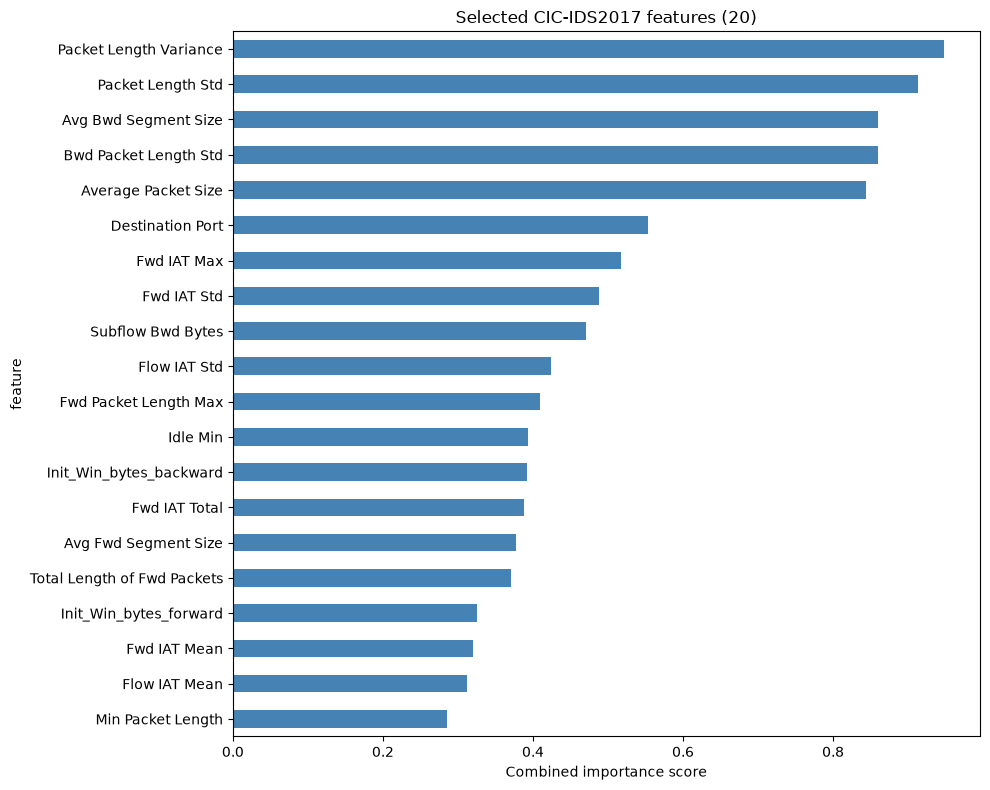

In [21]:
if RUN_FEATURE_SELECTION:
    FEATURE_FOLDER.mkdir(parents=True, exist_ok=True)

    feature_scores["redundant_with"] = pd.Series(removed_features).reindex(feature_scores.index)
    feature_scores["selected"] = feature_scores.index.isin(selected_features)
    feature_scores.to_csv(FEATURE_FOLDER / "feature_scores.csv")
    feature_correlation.to_csv(FEATURE_FOLDER / "feature_correlation.csv")

    selection_report = {
        "training_file": str(PROCESSED_FOLDER / "train.parquet"),
        "sample_rows": len(training_sample),
        "candidate_features": len(feature_scores),
        "constant_features": constant_features,
        "correlation_limit": CORRELATION_LIMIT,
        "redundant_features": removed_features,
        "selected_feature_count": len(selected_features),
        "selected_features": selected_features,
    }
    (FEATURE_FOLDER / "selected_features.json").write_text(
        json.dumps(selection_report, indent=2), encoding="utf-8"
    )

    top = feature_scores.loc[selected_features, "combined_score"].sort_values()
    figure, axis = plt.subplots(figsize=(10, 8))
    top.plot(kind="barh", color="steelblue", ax=axis)
    axis.set_title(f"Selected CIC-IDS2017 features ({len(selected_features)})")
    axis.set_xlabel("Combined importance score")
    figure.tight_layout()
    figure.savefig(FEATURE_FOLDER / "top_features.png", dpi=150)
    plt.show()

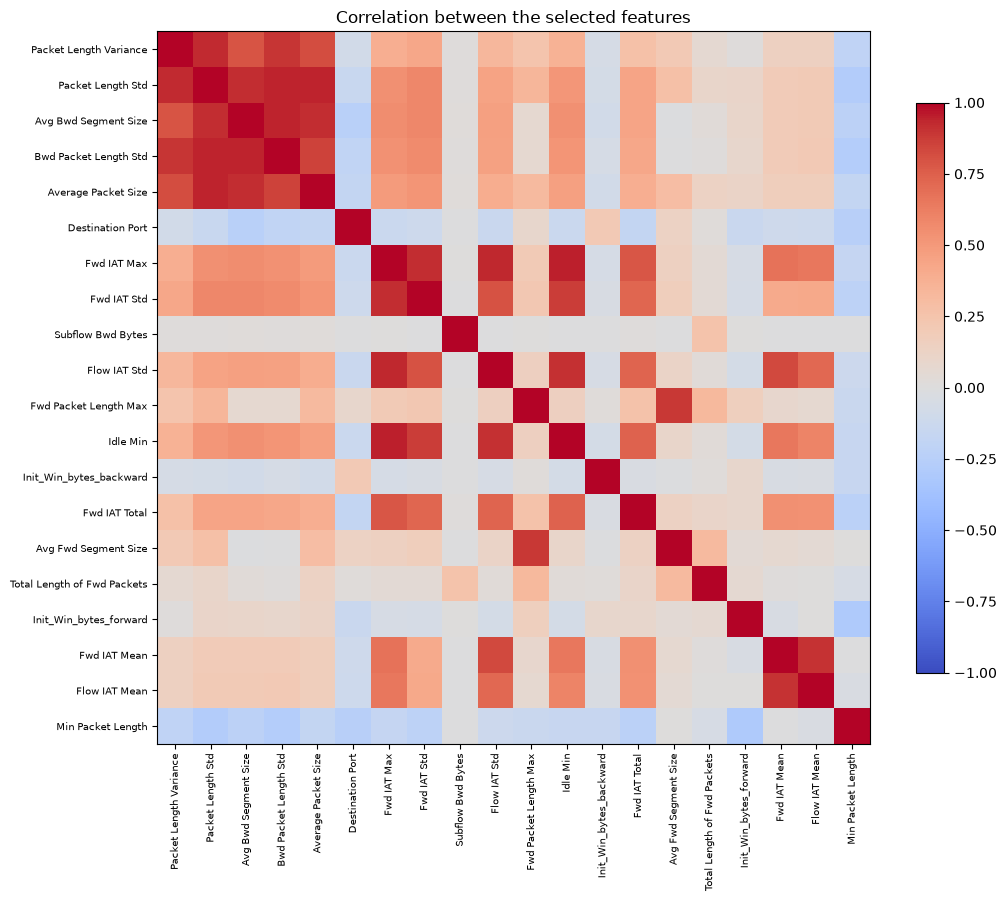

Largest absolute correlation between two selected features: 0.948


In [22]:
if RUN_FEATURE_SELECTION:
    matrix = feature_correlation.loc[selected_features, selected_features]
    figure, axis = plt.subplots(figsize=(11, 9))
    image = axis.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    axis.set_xticks(range(len(selected_features)), selected_features, rotation=90, fontsize=7)
    axis.set_yticks(range(len(selected_features)), selected_features, fontsize=7)
    axis.set_title("Correlation between the selected features")
    figure.colorbar(image, ax=axis, shrink=0.8)
    figure.tight_layout()
    figure.savefig(FEATURE_FOLDER / "selected_feature_correlation.png", dpi=150)
    plt.show()

    largest = matrix.where(~np.eye(len(matrix), dtype=bool)).abs().max().max()
    print(f"Largest absolute correlation between two selected features: {largest:.3f}")

## 12. View saved results

In [23]:
score_path = FEATURE_FOLDER / "feature_scores.csv"
if score_path.exists():
    saved_scores = pd.read_csv(score_path).set_index("feature")
    saved_selected = saved_scores[saved_scores["selected"]]
    display(saved_selected.round(4))
else:
    print("Set RUN_FEATURE_SELECTION = True and run the feature-selection cells.")

,rank,correlation,mutual_information,random_forest,combined_score,redundant_with,selected
feature,,,,,,,
Packet Length Variance,1,0.8789,0.9664,1.0000,0.9484,NaN,True
Packet Length Std,2,0.9397,0.9692,0.8320,0.9136,NaN,True
Avg Bwd Segment Size,3,0.9736,0.8552,0.7507,0.8598,NaN,True
Bwd Packet Length Std,4,1.0000,0.6888,0.8895,0.8595,NaN,True
Average Packet Size,5,0.8568,1.0000,0.6760,0.8442,NaN,True
Destination Port,10,0.2656,0.7788,0.6145,0.5530,NaN,True
Fwd IAT Max,11,0.7650,0.6593,0.1268,0.5170,NaN,True
Fwd IAT Std,13,0.8238,0.5163,0.1245,0.4882,NaN,True
Subflow Bwd Bytes,14,0.0024,0.8749,0.5347,0.4706,NaN,True
